In [1]:
# !git clone https://github.com/Thanh-Thanh-Thanh/thanh.git
# !pip install -r /content/thanh/requirements.txt

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# Import

In [3]:
import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


import sys
sys.path.append('../')
sys.path.append('/content/thanh/')
import sionna

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

sionna.config.seed = 42 # Set seed for reproducible random number generation

# Load the required Sionna components
from sionna.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver, CarrierConfig, PUSCHDMRSConfig,\
                        TBConfig, PUSCHPilotPattern, TBEncoder, PUSCHPrecoder, LayerMapper, LayerDemapper, check_pusch_configs,\
                        TBDecoder, PUSCHLSChannelEstimator
from sionna.nr.utils import generate_prng_seq
from sionna.channel import AWGN, RayleighBlockFading, OFDMChannel, TimeChannel, time_lag_discrete_time_channel
from sionna.channel.utils import *
from sionna.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa, TDL, CDL
from sionna.channel import gen_single_sector_topology as gen_topology
from sionna.utils import compute_ber, ebnodb2no, sim_ber, BinarySource
from sionna.ofdm import KBestDetector, LinearDetector, MaximumLikelihoodDetector,\
        LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper,\
        ResourceGrid, ResourceGridMapper, OFDMModulator
from sionna.mimo import StreamManagement
from sionna.mapping import Mapper, Demapper

from sionna.nr.my_abc import *

In [4]:
import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


import sys
sys.path.append('../')
sys.path.append('/content/thanh/')
import sionna

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

sionna.config.seed = 42 # Set seed for reproducible random number generation

# Load the required Sionna components
from sionna.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver, CarrierConfig, PUSCHDMRSConfig,\
                        TBConfig, PUSCHPilotPattern, TBEncoder, PUSCHPrecoder, LayerMapper, LayerDemapper, check_pusch_configs,\
                        TBDecoder, PUSCHLSChannelEstimator
from sionna.nr.utils import generate_prng_seq
from sionna.channel import AWGN, RayleighBlockFading, OFDMChannel, TimeChannel, time_lag_discrete_time_channel
from sionna.channel.utils import *
from sionna.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa, TDL, CDL
from sionna.channel import gen_single_sector_topology as gen_topology
from sionna.utils import compute_ber, ebnodb2no, sim_ber, BinarySource
from sionna.ofdm import KBestDetector, LinearDetector, MaximumLikelihoodDetector,\
        LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper,\
        ResourceGrid, ResourceGridMapper, OFDMModulator
from sionna.mimo import StreamManagement
from sionna.mapping import Mapper, Demapper

from sionna.nr.my_abc import *

In [5]:
# df = pd.read_parquet("/content/drive/MyDrive/Pusch_data/dataset/parquet/20250306172716144046.parquet", engine="pyarrow")

# Read field config

In [6]:
from pathlib import Path
import struct
import numpy as np
# Path to the data file
field_dir = '../Pusch_data/data_field'
data_path = f'{field_dir}/dump_pass_sfn_400_sf_4_freq.bin'
cfg_path = f'{field_dir}/dump_pass_sfn_400_sf_4_cfg.txt'

# data_path = "/content/dump_pass_sfn_919_sf_5_freq.bin"
# cfg_path = "/content/dump_pass_sfn_919_sf_5_cfg.txt"

freq = []

with open(data_path, 'rb') as file:
    binary_data = file.read()

    # Loop through the binary data in chunks of 2 bytes (since int16 is 2 bytes)
    for i in range(0, len(binary_data), 4):
        # Convert the chunk to an integer and append it to the list
        real = binary_data[i:i+2]
        imag = binary_data[i+2:i+4]

        #unpack the 2 bytes into a little-endian int16
        if len(real) == 2:
            real_part = struct.unpack('<h', real)[0]
            imag_part = struct.unpack('<h', imag)[0]
            freq.append(complex(real_part, imag_part))

freq = np.array(freq)
print(freq.shape)
# print("Unpacked int16 value:\n", freq)

# Load configuration parameters from the file .txt
caseInfo, sysInfo, ueInfo, chcfg, auxInfo = config_parser(cfg_path)

#reshape the iq data into resource grid (Numsubcarrier x 14 Sym x 8 ant)
freq = freq.reshape((sysInfo['BwpNRb']*12, 14, sysInfo['NRxAnt'], ))
print(freq.shape)
iqUe = freq[ueInfo[0]['FirstPrb']*12:(ueInfo[0]['NPrb'] + ueInfo[0]['FirstPrb'] + 1)*12,:, :]
iqUe = iqUe[np.newaxis,:]
iqUe = iqUe.astype(np.complex64)

(217728,)
(1944, 14, 8)


In [7]:
System_Config = SystemConfig(**sysInfo)

In [8]:
Ue_Configs = [UeConfig(**ue) for ue in ueInfo.values()]

In [9]:
My_Config = MyConfig(System_Config, Ue_Configs)
My_Config

MyConfig(Sys=SystemConfig(NCellId=442, FrequencyRange=1, BandWidth=60, Numerology=1, CpType=0, NTxAnt=1, NRxAnt=8, BwpNRb=162, BwpRbOffset=0, harqProcFlag=0, nHarqProc=1, rvSeq=0), Ue=[UeConfig(TransformPrecoding=0, Rnti=30025, nId=442, CodeBookBased=0, DmrsPortSetIdx=[0], NLayers=1, NumDmrsCdmGroupsWithoutData=2, Tpmi=0, FirstSymb=0, NPuschSymbAll=14, RaType=1, FirstPrb=32, NPrb=130, FrequencyHoppingMode=0, McsTable=0, Mcs=3, ILbrm=0, nScId=0, NnScIdId=442, DmrsConfigurationType=0, DmrsDuration=1, DmrsAdditionalPosition=2, PuschMappingType=0, DmrsTypeAPosition=3, HoppingMode=0, NRsId=0, Ptrs=0, ScalingFactor=0, OAck=4, IHarqAckOffset=11, OCsi1=0, ICsi1Offset=7, OCsi2=0, ICsi2Offset=0, NPrbOh=0, nCw=1, TpPi2Bpsk=0), UeConfig(TransformPrecoding=0, Rnti=30044, nId=442, CodeBookBased=0, DmrsPortSetIdx=[0], NLayers=1, NumDmrsCdmGroupsWithoutData=2, Tpmi=0, FirstSymb=0, NPuschSymbAll=14, RaType=1, FirstPrb=25, NPrb=7, FrequencyHoppingMode=0, McsTable=0, Mcs=0, ILbrm=0, nScId=0, NnScIdId=442

In [10]:
Pusch_Config = MyPUSCHConfig(My_Config)
Pusch_Config.show()

Carrier Configuration
cyclic_prefix : normal
cyclic_prefix_length : 2.3437500000000002e-06
frame_duration : 0.01
frame_number : 0
kappa : 64.0
mu : 1
n_cell_id : 442
n_size_grid : 162
n_start_grid : 0
num_slots_per_frame : 20
num_slots_per_subframe : 2
num_symbols_per_slot : 14
slot_number : 4
sub_frame_duration : 0.001
subcarrier_spacing : 30
t_c : 5.086263020833334e-10
t_s : 3.2552083333333335e-08

PUSCH Configuration
My_Config : MyConfig(Sys=SystemConfig(NCellId=442, FrequencyRange=1, BandWidth=60, Numerology=1, CpType=0, NTxAnt=1, NRxAnt=8, BwpNRb=162, BwpRbOffset=0, harqProcFlag=0, nHarqProc=1, rvSeq=0), Ue=[UeConfig(TransformPrecoding=0, Rnti=30025, nId=442, CodeBookBased=0, DmrsPortSetIdx=[0], NLayers=1, NumDmrsCdmGroupsWithoutData=2, Tpmi=0, FirstSymb=0, NPuschSymbAll=14, RaType=1, FirstPrb=32, NPrb=130, FrequencyHoppingMode=0, McsTable=0, Mcs=3, ILbrm=0, nScId=0, NnScIdId=442, DmrsConfigurationType=0, DmrsDuration=1, DmrsAdditionalPosition=2, PuschMappingType=0, DmrsTypeAPosit

In [11]:
ue_antenna = Antenna(polarization="single",
                polarization_type="V",
                antenna_pattern="38.901",
                carrier_frequency=2.55e9)

gnb_array = AntennaArray(num_rows=1,
                        num_cols=8//2,
                        polarization="dual",
                        polarization_type="cross",
                        antenna_pattern="38.901",
                        carrier_frequency=2.55e9)


In [12]:
iqUe.shape

(1, 1560, 14, 8)

In [13]:
y =  tf.concat([tf.math.real(iqUe), tf.math.imag(iqUe)], -1)
y.shape

TensorShape([1, 1560, 14, 16])

In [24]:
simulator = MySimulator(Pusch_Config)

channel_model = CDL(model = 'A',
                            delay_spread = 50*1e-9,
                            carrier_frequency = 2.55e9,
                            ut_array = ue_antenna,
                            bs_array = gnb_array,
                            direction = 'uplink',
                            min_speed = 1,
                            max_speed = 1)

channel = OFDMChannel(channel_model=channel_model, resource_grid=simulator.resource_grid,
                                    add_awgn=False, normalize_channel=True, return_channel=True)
b, c, y = simulator.sim(1, channel, 10.)
h_est,_,_,_ = simulator.rec(y)

In [25]:
channel_model = CDL(model = 'A',
                            delay_spread = 50*1e-9,
                            carrier_frequency = 2.55e9,
                            ut_array = ue_antenna,
                            bs_array = gnb_array,
                            direction = 'uplink',
                            min_speed = 1,
                            max_speed = 1)

b, c, y = simulator.sim(1, channel, .1)
h_est_2,_,_,_ = simulator.rec(y)

In [26]:
np.var(y), np.mean(y)

(1.0987798, (0.0077040396-0.0013117724j))

In [27]:
simulator.rec(y)

(<tf.Tensor: shape=(1, 1, 8, 1, 1, 14, 1560), dtype=complex64, numpy=
 array([[[[[[[ 1.1078603e+00+0.24320728j,  1.1078603e+00+0.24320728j,
               1.1078603e+00+0.24320728j, ...,
               6.9862497e-01+0.54035723j,  6.9862497e-01+0.54035723j,
               6.9862497e-01+0.54035723j],
             [ 1.1078603e+00+0.24320728j,  1.1078603e+00+0.24320728j,
               1.1078603e+00+0.24320728j, ...,
               6.9862497e-01+0.54035723j,  6.9862497e-01+0.54035723j,
               6.9862497e-01+0.54035723j],
             [ 1.1078603e+00+0.24320728j,  1.1078603e+00+0.24320728j,
               1.1078603e+00+0.24320728j, ...,
               6.9862497e-01+0.54035723j,  6.9862497e-01+0.54035723j,
               6.9862497e-01+0.54035723j],
             ...,
             [ 1.2468187e+00+0.5182199j ,  1.2468187e+00+0.5182199j ,
               1.2468187e+00+0.5182199j , ...,
               7.1687979e-01+0.8274931j ,  7.1687979e-01+0.8274931j ,
               7.1687979e-01+0.8274

In [28]:
iq_ue = tf.transpose(iqUe[None], [0,1,4,3,2])
np.std(iq_ue), np.mean(iq_ue)

(339.1927, (-1.0555975-1.5187614j))

In [29]:
h_est_field,_,b_rec_field,crc = simulator.rec(iq_ue)

In [30]:
crc

<tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[ True]])>

In [31]:
x_iq_field = simulator.Resource_Grid_Mapper(
                simulator.Layer_Mapper(
                    simulator.Constellation_Mapper(
                        simulator.TB_Encoder(b_rec_field)
                        )
                    )
                )

In [32]:
# Mask of NaN values
tf_tensor = (iq_ue/x_iq_field)[0, 0, 0, :, :]
# Separate real and imaginary parts
real_part = tf.math.real(tf_tensor)
imag_part = tf.math.imag(tf_tensor)
def fill_nan_nearest(tensor):
    nan_mask = tf.math.is_nan(tensor)
    filled_tensor = tf.where(nan_mask, tf.constant(-1e6, dtype=tf.float32), tensor)
    filled_tensor = tf.expand_dims(tf.expand_dims(filled_tensor, axis=0), axis=-1)
    filled_tensor = tf.image.resize(filled_tensor, tensor.shape, method='nearest')
    filled_tensor = tf.squeeze(filled_tensor)
    filled_tensor = tf.where(filled_tensor < -1e5, tf.constant(np.nan, dtype=tf.float32), filled_tensor)
    return filled_tensor

# Apply the function to real and imaginary parts separately
filled_real = fill_nan_nearest(real_part)
filled_imag = fill_nan_nearest(imag_part)

# Combine back into complex tensor
filled_tensor = tf.complex(filled_real, filled_imag)

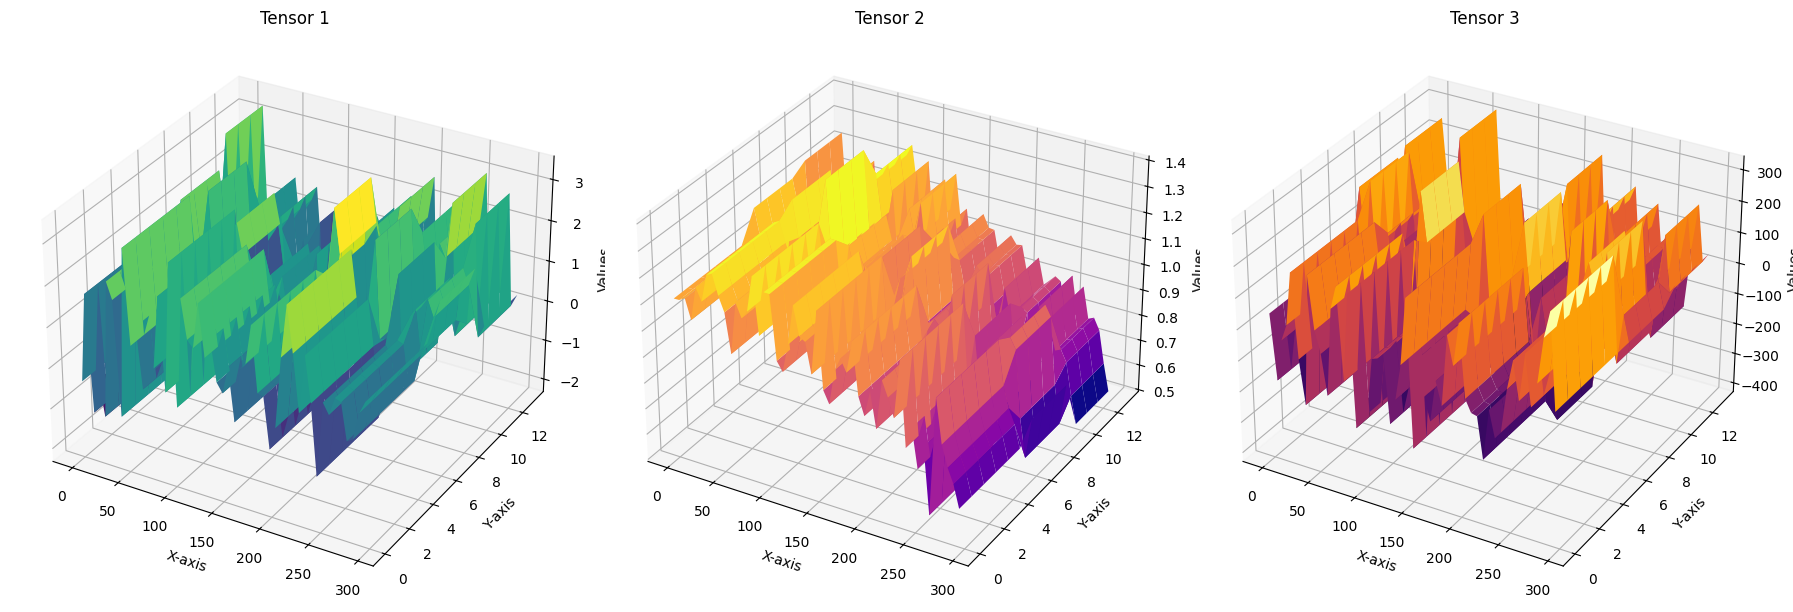

In [39]:
import numpy as np
import matplotlib.pyplot as plt

kkk = 300  # Example with large kkk

tensor1 = h_est[0, 0, 0, 0, 0, :, :kkk]  # Assuming shape (14, 8, X)
tensor2 = h_est_2[0, 0, 0, 0, 0, :, :kkk]  # Assuming shape (14, 8, X)
tensor3 = h_est_field[0, 0, 0, 0, 0, :, :kkk]  # Assuming shape (14, 8, X)
# tensor4 = filled_tensor[:, :kkk] 

x = np.arange(kkk)
y = np.arange(14)
x, y = np.meshgrid(x, y)

fig = plt.figure(figsize=(18, 6))

# Use subplot 131, 132, 133 for separate plots
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
# ax4 = fig.add_subplot(144, projection='3d')

# Downsample if needed (optional)
downsample_factor = max(1, kkk // 50)  # Keep at most 50 points in kkk direction
x_down, y_down = x[:, ::downsample_factor], y[:, ::downsample_factor]
tensor1_down = tensor1[:, ::downsample_factor]
tensor2_down = tensor2[:, ::downsample_factor]
tensor3_down = tensor3[:, ::downsample_factor]
# tensor4_down = tensor4[:, ::downsample_factor]

ax1.plot_surface(x_down, y_down, tensor1_down, cmap='viridis')
ax1.set_title("Tensor 1")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_zlabel("Values")

ax2.plot_surface(x_down, y_down, tensor2_down, cmap='plasma')
ax2.set_title("Tensor 2")
ax2.set_xlabel("X-axis")
ax2.set_ylabel("Y-axis")
ax2.set_zlabel("Values")

ax3.plot_surface(x_down, y_down, tensor3_down, cmap='inferno')
ax3.set_title("Tensor 3")
ax3.set_xlabel("X-axis")
ax3.set_ylabel("Y-axis")
ax3.set_zlabel("Values")

# ax4.plot_surface(x_down, y_down, tensor4_down, cmap='magma')
# ax4.set_title("Tensor 4")
# ax4.set_xlabel("X-axis")
# ax4.set_ylabel("Y-axis")
# ax4.set_zlabel("Values")

plt.tight_layout()
plt.show()


# Eval model

In [19]:
_model = CustomNeuralReceiver(training = True)
inputs = tf.zeros([1,3276,14,16])
_model(inputs)
_model.summary()

#load_weights(_model, '/content/drive/MyDrive/Pusch_data/Model_weights/model_weight_FULL_RB_epoch_40.pkl')
# load_weights(_model, '../model_weight_FULL_RB_epoch_40.pkl')
load_weights(_model, '../273_RB_hdf5_data.pkl')

Model: "custom_neural_receiver"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             multiple                  18560     
                                                                 
 residual_block (ResidualBl  multiple                  23777536  
 ock)                                                            
                                                                 
 residual_block_1 (Residual  multiple                  23777536  
 Block)                                                          
                                                                 
 residual_block_2 (Residual  multiple                  23777536  
 Block)                                                          
                                                                 
 residual_block_3 (Residual  multiple                  23777536  
 Block)                                     

In [74]:
sysCfg = SystemConfig(
    NCellId = 246,
    FrequencyRange = 1,
    BandWidth = 100,
    Numerology = 1,
    CpType = 0,
    NTxAnt = 1,
    NRxAnt = 8,
    BwpNRb = 273,
    BwpRbOffset = 0,
    harqProcFlag = 0,
    nHarqProc = 1,
    rvSeq = 0
)
ueCfg = UeConfig(
    TransformPrecoding = 0,
    Rnti = 1,
    nId = 246,
    CodeBookBased = 0,
    DmrsPortSetIdx = [0],
    NLayers = 1,
    NumDmrsCdmGroupsWithoutData = 2,
    Tpmi = 0,
    FirstSymb = 0,
    NPuschSymbAll = 14,
    RaType = 1,
    FirstPrb = 0,
    NPrb = 273,
    FrequencyHoppingMode = 0,
    McsTable = 0,
    Mcs = 9,
    ILbrm = 0,
    nScId = 0,
    NnScIdId = 246,
    DmrsConfigurationType = 0,
    DmrsDuration = 1,
    DmrsAdditionalPosition = 1,
    PuschMappingType = 0,
    DmrsTypeAPosition = 3,
    HoppingMode = 0,
    NRsId = 0,
    Ptrs = 0,
    ScalingFactor = 0,
    OAck = 0,
    IHarqAckOffset = 11,
    OCsi1 = 0,
    ICsi1Offset = 7,
    OCsi2 = 0,
    ICsi2Offset = 0,
    NPrbOh = 0,
    nCw = 1,
    TpPi2Bpsk = 0
)
MyCfg = MyConfig(sysCfg, [ueCfg])
MyPuschCfg = MyPUSCHConfig(MyCfg, 4)
MyPuschCfg.show()

Carrier Configuration
cyclic_prefix : normal
cyclic_prefix_length : 2.3437500000000002e-06
frame_duration : 0.01
frame_number : 0
kappa : 64.0
mu : 1
n_cell_id : 246
n_size_grid : 273
n_start_grid : 0
num_slots_per_frame : 20
num_slots_per_subframe : 2
num_symbols_per_slot : 14
slot_number : 4
sub_frame_duration : 0.001
subcarrier_spacing : 30
t_c : 5.086263020833334e-10
t_s : 3.2552083333333335e-08

PUSCH Configuration
My_Config : MyConfig(Sys=SystemConfig(NCellId=246, FrequencyRange=1, BandWidth=100, Numerology=1, CpType=0, NTxAnt=1, NRxAnt=8, BwpNRb=273, BwpRbOffset=0, harqProcFlag=0, nHarqProc=1, rvSeq=0), Ue=[UeConfig(TransformPrecoding=0, Rnti=1, nId=246, CodeBookBased=0, DmrsPortSetIdx=[0], NLayers=1, NumDmrsCdmGroupsWithoutData=2, Tpmi=0, FirstSymb=0, NPuschSymbAll=14, RaType=1, FirstPrb=0, NPrb=273, FrequencyHoppingMode=0, McsTable=0, Mcs=9, ILbrm=0, nScId=0, NnScIdId=246, DmrsConfigurationType=0, DmrsDuration=1, DmrsAdditionalPosition=1, PuschMappingType=0, DmrsTypeAPosition=

In [75]:
def loss_cal(pred, labels):
  bce = tf.nn.sigmoid_cross_entropy_with_logits(labels, pred)
  bce = tf.reduce_mean(bce)
  # rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
  # loss = -rate
  loss = bce
  return loss


In [76]:
simulator = MySimulator(MyPuschCfg)
channel = OFDMChannel(channel_model=channel_model, resource_grid=simulator.resource_grid,
                                    add_awgn=False, normalize_channel=True, return_channel=True)
b, c, y, x = simulator.sim(8, channel, 1., 20044)
b_hat, c_soft, crc = simulator.rec(y)
print(crc)

tf.Tensor(
[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]], shape=(8, 1), dtype=bool)


In [77]:
r_3 = x[:,:,:,3,:]
r_11 = x[:,:,:,11,:]
r_3 = tf.where(r_3 == 0, 1, r_3)
r_11 = tf.where(r_11 == 0, 1, r_11)

In [78]:
y.shape

TensorShape([8, 1, 8, 14, 3276])

In [79]:
def predict(model, y, sc_0):
    # y shape=(1,1,8,14,nSubcs)
    # need inputs shape=(1,3276,14,16)
    y = tf.concat([tf.math.real(y), tf.math.imag(y)], axis=2) # shape=(1,1,16,14,nSubcs)
    y = y[:,0] # shape=(1,16,14,nSubcs)
    # inputs = tf.tile(inputs, [1,1,1,(3276/inputs.shape[-1]).__ceil__()])
    # inputs = inputs[...,:3276]
    y = tf.transpose(y, [0,3,2,1]) # shape=(1,nSubcs,14,16)
    inputs = tf.Variable(tf.zeros([y.shape[0],3276,14,16], dtype=tf.float32))

    inputs[:,sc_0:sc_0+y.shape[1]].assign(y)
    print(inputs.shape)
    preds = model(inputs)
    print(preds.shape)
    preds = tf.reshape(preds, [preds.shape[0], 12, 3276, 2])
    preds = preds[...,sc_0:sc_0+y.shape[1],:]
    # preds = tf.reshape(preds, [preds.shape[0], 1, 12*y.shape[1]*2])

    return preds

In [80]:
def evaluate(preds, c_label):
    loss = loss_cal(preds, c_label)
    return loss

In [81]:
sc_0 = MyPuschCfg.first_subcarrier
preds = predict(_model, y, sc_0)
c_pred = tf.reshape(preds, [preds.shape[0], 1, 12*y.shape[-1]*2])
loss = evaluate(c_pred, c)
_,crc = simulator.TB_Decode(c_pred)
loss, crc

(8, 3276, 14, 16)
(8, 78624)


(<tf.Tensor: shape=(), dtype=float32, numpy=0.025580863>,
 <tf.Tensor: shape=(8, 1), dtype=bool, numpy=
 array([[ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True]])>)

In [82]:
MyPuschCfg_2 = MyPuschCfg.clone()
MyPuschCfg_2.phy_cell_id = 123
simulator = MySimulator(MyPuschCfg_2)
channel = OFDMChannel(channel_model=channel_model, resource_grid=simulator.resource_grid,
                                    add_awgn=False, normalize_channel=True, return_channel=True)
b_2, c_2, y_2, x_2 = simulator.sim(8, channel, 1., 20044)
b_hat, c_soft, crc = simulator.rec(y_2)
print(crc)

tf.Tensor(
[[ True]
 [ True]
 [False]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]], shape=(8, 1), dtype=bool)


In [83]:
r_2_3 = x_2[:,:,:,3,:]
r_2_11 = x_2[:,:,:,11,:]
r_2_3 = tf.where(r_2_3 == 0, 1, r_2_3)
r_2_11 = tf.where(r_2_11 == 0, 1, r_2_11)

In [84]:
sc_2_0 = MyPuschCfg_2.first_subcarrier
preds = predict(_model, y_2, sc_2_0)
c_pred = tf.reshape(preds, [preds.shape[0], 1, 12*y_2.shape[-1]*2])
loss = evaluate(c_pred, c)
_,crc = simulator.TB_Decode(c_pred)
loss, crc

(8, 3276, 14, 16)
(8, 78624)


(<tf.Tensor: shape=(), dtype=float32, numpy=5.0917077>,
 <tf.Tensor: shape=(8, 1), dtype=bool, numpy=
 array([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])>)

In [85]:
y_2_new = tf.Variable(y_2)
y_2_new[...,3,:].assign(y_2[...,3,:]*r_3/r_2_3)
y_2_new[...,11,:].assign(y_2[...,11,:]*r_11/r_2_11)

<tf.Variable 'UnreadVariable' shape=(8, 1, 8, 14, 3276) dtype=complex64, numpy=
array([[[[[-4.97834027e-01+4.58425760e-01j,
           -6.83837056e-01+4.54154938e-01j,
            8.47915471e-01+6.99712276e-01j, ...,
            4.27294970e-01-2.85631835e-01j,
           -7.85432696e-01-7.84270346e-01j,
           -5.38801193e-01-6.07408762e-01j],
          [ 6.46047354e-01-7.54780114e-01j,
            1.00826156e+00+1.33005768e-01j,
           -4.96254176e-01+5.35736978e-01j, ...,
           -1.70477629e-02+1.43167883e-01j,
            1.29052818e-01+2.35911012e-02j,
            2.71518826e-01+2.43270111e+00j],
          [-2.62248039e-01-5.23826063e-01j,
           -1.06566954e+00-4.03731585e-01j,
            1.13661081e-01-1.38365006e+00j, ...,
           -1.78701252e-01+5.57643831e-01j,
           -1.77530736e-01-1.02049017e+00j,
            3.23401392e-01-6.99633241e-01j],
          ...,
          [-5.27279377e-02+1.27378428e+00j,
           -9.21002507e-01+6.93832457e-01j,
       

In [86]:
sc_2_0 = MyPuschCfg_2.first_subcarrier
preds = predict(_model, y_2_new, sc_2_0)
c_pred = tf.reshape(preds, [preds.shape[0], 1, 12*y_2_new.shape[-1]*2])
loss = evaluate(c_pred, c)
_,crc = simulator.TB_Decode(c_pred)
loss, crc

(8, 3276, 14, 16)
(8, 78624)


(<tf.Tensor: shape=(), dtype=float32, numpy=12.701334>,
 <tf.Tensor: shape=(8, 1), dtype=bool, numpy=
 array([[ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True],
        [ True]])>)

In [87]:
Field_config = Pusch_Config.clone()
simulator = MySimulator(Field_config)
channel = OFDMChannel(channel_model=channel_model, resource_grid=simulator.resource_grid,
                                    add_awgn=False, normalize_channel=True, return_channel=True)
b_field, c_field, y_field, x_field = simulator.sim(8, channel, 1., 20044)
b_hat, c_soft, crc = simulator.rec(y_field)
sc_field_0 = Field_config.first_subcarrier
print(crc)

tf.Tensor(
[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]], shape=(8, 1), dtype=bool)


In [88]:
r_field_3 = x_field[:,:,:,3,:]
r_field_11 = x_field[:,:,:,11,:]
r_field_3 = tf.where(r_field_3 == 0, 1, r_field_3)
r_field_11 = tf.where(r_field_11 == 0, 1, r_field_11)

In [89]:
y_field_new = tf.Variable(y_field)
y_field_new[...,3,:].assign(y_field[...,3,:]*r_3[...,sc_field_0:sc_field_0+y_field.shape[-1]]/r_field_3)
y_field_new[...,11,:].assign(y_field[...,11,:]*r_11[...,sc_field_0:sc_field_0+y_field.shape[-1]]/r_field_11)

<tf.Variable 'UnreadVariable' shape=(8, 1, 8, 14, 1560) dtype=complex64, numpy=
array([[[[[ 1.71723831e+00+8.17705512e-01j,
            4.29858118e-01+5.95468104e-01j,
            5.75954437e-01+8.73977304e-01j, ...,
           -8.90750766e-01+1.14191628e+00j,
           -1.05281973e+00+1.11558449e+00j,
           -8.76596332e-01-9.45621133e-01j],
          [ 1.88118362e+00-9.07498002e-02j,
            5.53601980e-03-3.92829299e-01j,
           -6.87179148e-01+7.34711885e-01j, ...,
            1.52787852e+00+1.58321500e-01j,
            2.11745000e+00-2.23057926e-01j,
            4.86909926e-01-7.75573492e-01j],
          [ 1.70058322e+00+1.27424645e+00j,
           -8.61860394e-01+1.39947474e-01j,
            3.28636110e-01-1.36145973e+00j, ...,
           -9.44045842e-01-7.72879422e-01j,
           -6.85413718e-01+9.68788385e-01j,
           -1.24493492e+00+6.27315521e-01j],
          ...,
          [-1.67138028e+00+1.77536726e-01j,
           -8.62274051e-01+2.58859098e-01j,
       

In [90]:
y_field.shape[-1]

1560

In [91]:
12*y_field.shape[-1]*2

37440

In [92]:
c_pred

<tf.Tensor: shape=(8, 1, 78624), dtype=float32, numpy=
array([[[-10.559133 , -14.995221 ,  13.888203 , ..., -17.002361 ,
          -9.161128 ,  -2.8586318]],

       [[ -7.3599124,  13.053924 , -27.908379 , ..., -14.02138  ,
          10.770345 ,  13.565686 ]],

       [[ 17.5909   ,  17.344772 , -26.790941 , ..., -18.879755 ,
          -9.451147 ,  -4.901184 ]],

       ...,

       [[  8.686868 ,  14.1672535, -19.344788 , ..., -19.803122 ,
          -4.0688896,  16.00581  ]],

       [[-11.779967 ,  23.683628 , -32.210472 , ...,  26.26033  ,
         -17.320776 , -13.229427 ]],

       [[ 14.592415 ,  14.178015 , -30.28888  , ...,  17.863712 ,
           8.299497 , -10.887982 ]]], dtype=float32)>

In [93]:
preds = predict(_model, y_field_new, sc_field_0)
c_pred = tf.reshape(preds, [preds.shape[0], 1, 12*y_field.shape[-1]*2])
_,crc = simulator.TB_Decode(c_pred)
crc

(8, 3276, 14, 16)


(8, 78624)


InvalidArgumentError: Exception encountered when calling layer 'tb_decoder_9' (type TBDecoder).

{{function_node __wrapped__Reshape_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input to reshape is a tensor with 299520 values, but the requested shape requires a multiple of 34320 [Op:Reshape]

Call arguments received by layer 'tb_decoder_9' (type TBDecoder):
  • inputs=tf.Tensor(shape=(8, 1, 37440), dtype=float32)

In [ ]:
y_iq_field = tf.transpose(iqUe, [0, 3, 2, 1])[:,None]

In [ ]:
sc_field_0 = Field_config.first_subcarrier
preds = predict(_model, y_iq_field, sc_field_0)
c_pred = tf.reshape(preds, [preds.shape[0], 1, 12*y_field.shape[-1]*2])
# loss = evaluate(c_pred, c_field)
_,crc = simulator.TB_Decode(c_pred)
crc, loss_cal(c_pred, c_rec_field)

(1, 3276, 14, 16)
(1, 78624)


(<tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[False]])>,
 <tf.Tensor: shape=(), dtype=float32, numpy=56.289955>)

In [ ]:
r_3.shape

TensorShape([8, 1, 1, 3276])

In [ ]:
y_iq_field.shape

TensorShape([1, 1, 8, 14, 1644])

In [ ]:
norm_y_iq_field = y_iq_field/np.max(np.abs(y_iq_field))*30

In [ ]:
y_field_new = tf.Variable(norm_y_iq_field)
y_field_new[...,3,:].assign(norm_y_iq_field[...,3,:]*r_3[0,...,sc_field_0:sc_field_0+y_field.shape[-1]]/r_field_3[0])
y_field_new[...,11,:].assign(norm_y_iq_field[...,11,:]*r_11[0,...,sc_field_0:sc_field_0+y_field.shape[-1]]/r_field_11[0])

<tf.Variable 'UnreadVariable' shape=(1, 1, 8, 14, 1644) dtype=complex64, numpy=
array([[[[[-1.3225336 -1.4901787j , -0.0558817 -0.81959826j,
            3.2411385 -1.0803795j , ..., -1.3039063 -0.7637166j ,
           -0.03725446+1.359788j  , -0.63332593-0.6146987j ],
          [ 3.0921206 -1.993114j  ,  1.0058706 -0.35391742j,
           -1.4156697 -2.3284042j , ..., -1.676451  -3.3901565j ,
           -1.1735157 +2.8127122j , -0.8568527 +0.57744426j],
          [ 2.6823215 +0.44705358j, -2.6078126 -0.89410716j,
            1.2107701 +1.8999778j , ..., -2.6823215 +1.0803795j ,
            1.6578238 +1.285279j  , -1.6578238 -1.7509599j ],
          ...,
          [ 2.0303683 -0.29803568j,  1.4715514 -4.135246j  ,
            0.78234386+4.0234823j , ...,  0.35391742+2.0303683j ,
           -0.46568084+0.39117187j,  0.72646207-0.14901786j],
          [-0.31666297+1.5274332j ,  0.81959826+5.2901344j ,
           -0.74508935+2.4587948j , ..., -0.26078126+1.5274332j ,
            0.1117634 

In [ ]:
sc_field_0 = Field_config.first_subcarrier
preds = predict(_model, y_field_new, sc_field_0)
c_pred = tf.reshape(preds, [preds.shape[0], 1, 12*y_field.shape[-1]*2])
_,crc = simulator.TB_Decode(c_pred)
crc, loss_cal(c_pred, c_rec_field)

(1, 3276, 14, 16)
(1, 78624)


(<tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[False]])>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1.4466941>)

In [ ]:
simulator.rec(y_iq_field)

(<tf.Tensor: shape=(1, 1, 23040), dtype=float32, numpy=array([[[0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 1, 1, 39456), dtype=float32, numpy=
 array([[[[-19342738.  ,   4531224.  , -13832809.  , ...,   -916895.25,
            -5954067.  ,   9292215.  ]]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[ True]])>)

In [ ]:
simulator.rec(norm_y_iq_field)

(<tf.Tensor: shape=(1, 1, 23040), dtype=float32, numpy=array([[[1., 1., 0., ..., 0., 0., 0.]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 1, 1, 39456), dtype=float32, numpy=
 array([[[[-1493.5839 ,   372.56537, -1087.5713 , ...,   -50.07077,
            -424.73944,   676.0386 ]]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[False]])>)

# ABC

In [140]:
tf.math.reduce_sum(x, [0,1,2,4]), tf.math.reduce_sum(tf.gather(x,[0,1,2,4,5,6,7,8,9,10,12,13],axis=3), [0,1,2,3])

(<tf.Tensor: shape=(14,), dtype=complex64, numpy=
 array([ -35.355354  +32.526924j ,   -1.4142156 +16.97056j  ,
          -2.8284287-179.60529j  ,  720.       +464.j       ,
          22.627419  -83.43866j  ,  -46.669075 -104.651886j ,
          38.183784  -26.870064j ,  -83.43867   +74.95338j  ,
         -49.49751   -57.982796j ,  205.06114  +222.03172j  ,
          97.58081    +1.4142232j, -128.       +336.j       ,
         158.39206   -66.46809j  ,    8.485282 +114.55139j  ],
       dtype=complex64)>,
 <tf.Tensor: shape=(3276,), dtype=complex64, numpy=
 array([-11.313707 -1.4142137j,  -7.071068 -8.48528j  ,
        -12.727921 -5.6568537j, ...,   2.8284268+9.899494j ,
         -5.656854 +5.6568527j,   4.2426405+5.656854j ], dtype=complex64)>)

In [ ]:
(<tf.Tensor: shape=(14,), dtype=complex64, numpy=
 array([-42.4264   +53.740105j ,   5.656852 +16.97057j  ,
         32.526917  +8.485275j ,  90.       +58.j       ,
          2.828414 -21.213194j , -32.52691  +12.727925j ,
         39.597977 -22.627415j , -28.284267 -59.396954j ,
          9.8994875-15.556346j ,  11.313706 -53.740105j ,
        -55.15432  +52.325893j , -16.       +42.j       ,
          8.485271 -22.627415j ,  -9.899492  +5.6568584j], dtype=complex64)>,
 <tf.Tensor: shape=(3276,), dtype=complex64, numpy=
 array([ 1.4142135e+00-2.8284268j, -1.1920929e-07-1.4142135j,
         4.2426405e+00-1.4142134j, ...,  1.4142134e+00-1.4142137j,
         5.6568537e+00+1.4142135j,  2.8284271e+00-4.2426405j],
       dtype=complex64)>)

SyntaxError: invalid syntax (1128591820.py, line 1)

In [ ]:
<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([ 4.24264717e+00-26.870052j , -3.81469727e-06+11.313685j ,
        3.67695389e+01-32.526905j ,  9.00000000e+01+58.j       ,
        1.13137074e+01+55.154327j ,  3.67695503e+01+38.183754j ,
        3.25269012e+01-46.66904j  , -1.13137102e+01+33.94113j  ,
        7.49533234e+01-33.941116j ,  6.08111763e+01-15.556354j ,
        5.51543198e+01-50.911682j , -1.60000000e+01+42.j       ,
       -1.41421385e+01 +7.0710745j, -3.67695541e+01+73.53909j  ],
      dtype=complex64)>

In [ ]:
<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([ 4.24264717e+00-26.870052j , -3.81469727e-06+11.313685j ,
        3.67695389e+01-32.526905j ,  4.00000000e+01-26.j       ,
        1.13137074e+01+55.154327j ,  3.67695503e+01+38.183754j ,
        3.25269012e+01-46.66904j  , -1.13137102e+01+33.94113j  ,
        7.49533234e+01-33.941116j ,  6.08111763e+01-15.556354j ,
        5.51543198e+01-50.911682j , -2.60000000e+01 +4.j       ,
       -1.41421385e+01 +7.0710745j, -3.67695541e+01+73.53909j  ],
      dtype=complex64)>
<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([ 32.5269  -33.94113j  ,  -8.485283-49.49747j  ,
       -55.154324-36.76953j  , -42.      +18.j       ,
         8.485287-28.284264j ,  33.941116-77.78174j  ,
        33.94113  -1.4142265j, -14.142132 -8.485283j ,
       -18.384773-35.35534j  ,  79.19597 +11.313709j ,
        41.012184+86.267044j ,   8.      -44.j       ,
       -22.627407-50.911667j ,  -5.656855-32.526917j ], dtype=complex64)>
<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([ 32.5269  -33.94113j  ,  -8.485283-49.49747j  ,
       -55.154324-36.76953j  ,  90.      +48.j       ,
         8.485287-28.284264j ,  33.941116-77.78174j  ,
        33.94113  -1.4142265j, -14.142132 -8.485283j ,
       -18.384773-35.35534j  ,  79.19597 +11.313709j ,
        41.012184+86.267044j , -10.      +16.j       ,
       -22.627407-50.911667j ,  -5.656855-32.526917j ], dtype=complex64)>

SyntaxError: invalid syntax (3658510392.py, line 1)

In [ ]:
y_3276 = tf.tile(y, [1,1,1,1,(3276/y.shape[-1]).__ceil__()])
y_3276 = y_3276[...,:3276][0]
y_3276.shape

TensorShape([1, 8, 14, 3276])

In [ ]:
pred = _model(
        tf.transpose(
            tf.concat([tf.math.real(y_3276), tf.math.imag(y_3276)], 1),
            [0,3,2,1]
        )
    )
pred

<tf.Tensor: shape=(1, 78624), dtype=float32, numpy=
array([[ 3.454744 , -4.9079275, -1.5192786, ..., -5.925903 , -4.748873 ,
        10.5194435]], dtype=float32)>

In [ ]:
pred_cut = tf.concat([pred[...,0:2,:], pred[...,3:11,:], pred[...,12:14,:]], -2)
pred_cut

<tf.Tensor: shape=(1, 78624), dtype=float32, numpy=
array([[ 3.454744 , -4.9079275, -1.5192786, ..., -5.925903 , -4.748873 ,
        10.5194435]], dtype=float32)>

In [ ]:
loss_cal(pred_cut, c[0])

<tf.Tensor: shape=(), dtype=float32, numpy=3.4020863>

In [ ]:
b_hat, tb_crc_status = simulator.TB_Decode(pred_cut)
tb_crc_status

<tf.Tensor: shape=(1,), dtype=bool, numpy=array([False])>

In [ ]:
compute_ber(b, b_hat)

<tf.Tensor: shape=(), dtype=float64, numpy=0.5024892769607843>

In [ ]:
# loss_cal(tf.reshape(tf.transpose(pred_cut, [0, 2, 1, 3]), [1, -1]), c[0])

InvalidArgumentError: {{function_node __wrapped__Transpose_device_/job:localhost/replica:0/task:0/device:CPU:0}} transpose expects a vector of size 2. But input(1) is a vector of size 4 [Op:Transpose]

In [ ]:
b_hat, tb_crc_status = simulator.TB_Decode(tf.reshape(tf.transpose(pred_cut, [0, 2, 1, 3]), [1, -1]))
tb_crc_status

InvalidArgumentError: {{function_node __wrapped__Transpose_device_/job:localhost/replica:0/task:0/device:CPU:0}} transpose expects a vector of size 2. But input(1) is a vector of size 4 [Op:Transpose]

In [ ]:
y.shape

TensorShape([1, 1, 8, 14, 3276])

In [ ]:
iqUe.shape

(1, 1644, 14, 8)

In [ ]:
b_hat, c_soft, crc = simulator.rec(tf.transpose(iqUe, [0, 3, 2, 1])[None])
crc

InvalidArgumentError: Exception encountered when calling layer 'remove_nulled_subcarriers_2' (type RemoveNulledSubcarriers).

{{function_node __wrapped__GatherV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} indices[1644] = 1644 is not in [0, 1644) [Op:GatherV2]

Call arguments received by layer 'remove_nulled_subcarriers_2' (type RemoveNulledSubcarriers):
  • inputs=tf.Tensor(shape=(1, 1, 8, 14, 1644), dtype=complex64)

In [ ]:
pred_res[:,:1644]

<tf.Tensor: shape=(12, 1644, 2), dtype=float32, numpy=
array([[[ -71.63774  ,  -85.060326 ],
        [ 116.95443  , -148.9618   ],
        [-260.9698   ,  138.34946  ],
        ...,
        [ 139.71997  ,  -28.929968 ],
        [   6.311607 ,  -17.734463 ],
        [-124.0631   ,  148.38802  ]],

       [[  -4.5272717,   82.931755 ],
        [-100.03425  ,  106.010475 ],
        [  67.62827  ,  -78.62356  ],
        ...,
        [  41.724415 ,   83.79933  ],
        [ 125.243126 , -220.15167  ],
        [ 146.10907  ,   92.429436 ]],

       [[  31.48144  , -104.126915 ],
        [  -8.711629 ,  126.89084  ],
        [ -90.887856 ,   58.21057  ],
        ...,
        [  54.87343  ,   76.09623  ],
        [-151.29193  ,   74.334526 ],
        [  44.366074 , -271.40506  ]],

       ...,

       [[  16.706966 ,  -91.25626  ],
        [ 265.0703   ,   21.292778 ],
        [ -20.441639 ,  131.47733  ],
        ...,
        [  26.542274 ,   21.892067 ],
        [  45.86224  ,  -82.0917   ],


In [ ]:
tf.reshape(c_soft, [12, 1644, 2])

<tf.Tensor: shape=(12, 1644, 2), dtype=float32, numpy=
array([[[-1.9342738e+07,  4.5312240e+06],
        [-1.3832809e+07, -1.8378452e+06],
        [-1.6420532e+07,  1.1276512e+06],
        ...,
        [ 1.0888076e+07,  8.4914610e+06],
        [ 6.5768170e+06, -4.1146695e+06],
        [ 2.7613630e+07,  1.4099055e+06]],

       [[-1.8435924e+07, -1.6561740e+06],
        [-9.1237790e+06,  6.0531410e+06],
        [-1.0412488e+07,  2.3951016e+07],
        ...,
        [-2.6442084e+07, -1.0060939e+07],
        [ 4.5923910e+06,  9.2180480e+06],
        [-8.6107640e+06, -2.0792444e+07]],

       [[-2.7428528e+06, -1.0751866e+07],
        [ 1.1236838e+07,  2.8255728e+07],
        [-7.9739645e+06, -1.2676812e+07],
        ...,
        [ 1.6247827e+07, -7.0950595e+06],
        [ 8.6497830e+06, -1.8300286e+07],
        [-8.0780170e+06,  6.6603560e+06]],

       ...,

       [[ 6.1081541e+36,  1.2955886e+37],
        [-2.1103885e+37, -1.6265428e+38],
        [-1.2121125e+37,  2.2888413e+38],
     

In [ ]:
b_hat, tb_crc_status = simulator.TB_Decode(tf.reshape(pred_res[:,:1644],[1, -1]))
tb_crc_status

<tf.Tensor: shape=(1,), dtype=bool, numpy=array([False])>

In [ ]:
y_3276 = tf.pad(y, [[0,0], [0,0], [0,0], [0,0], [0,3276 - y.shape[-1]]], "REFLECT")

In [ ]:
ind_0 = tf.cast(simulator.Resource_Grid_Mapper._data_ind, dtype=tf.int32)
# Determine the number of rows in ind_0
num_rows = tf.shape(ind_0)[0]

# Create indices to target all rows in the second column (index 1)
row_indices = tf.range(num_rows)
column_index = tf.constant(1, shape=[num_rows])
indices = tf.stack([row_indices, column_index], axis=1)

# Create the updates tensor with the desired values
updates = tf.ones([num_rows], dtype=ind_0.dtype)

# Apply the tensor scatter update
ind_1 = tf.tensor_scatter_nd_update(ind_0, indices, updates)

In [ ]:
ind = tf.concat([ind_0, ind_1], axis = 0)
ind = tf.gather(ind, [0, 2, 3, 1], axis=1)
ind

<tf.Tensor: shape=(36960, 4), dtype=int32, numpy=
array([[   0,    0,    0,    0],
       [   0,    0,    1,    0],
       [   0,    0,    2,    0],
       ...,
       [   0,   13, 1677,    1],
       [   0,   13, 1678,    1],
       [   0,   13, 1679,    1]], dtype=int32)>

In [ ]:
def predict(y):

    # Concat Real and Image of y
    y = tf.concat([tf.math.real(y), tf.math.imag(y)], axis=2)
    y = y[:,0]
    y = tf.transpose(y, perm=[0,3,2,1])

    pred = _model(y)
    print(pred.shape)
    pred = tf.transpose(pred, perm=[0,2,1,3])
    print(pred.shape,  pred[*ind[0]])
    return tf.gather_nd(pred, [[ind]])


In [ ]:
sysCfg = SystemConfig(
    NCellId = 0,
    FrequencyRange = 1,
    BandWidth = 100,
    Numerology = 1,
    CpType = 0,
    NTxAnt = 1,
    NRxAnt = 8,
    BwpNRb = 273,
    BwpRbOffset = 0,
    harqProcFlag = 0,
    nHarqProc = 1,
    rvSeq = 0
)
ueCfg = UeConfig(
    rvIdx = 0,
    TransformPrecoding = 0,
    Rnti = 24241,
    nId = 0,
    CodeBookBased = 0,
    DmrsPortSetIdx = [0],
    NLayers = 1,
    NumDmrsCdmGroupsWithoutData = 2,
    Tpmi = 0,
    FirstSymb = 0,
    NPuschSymbAll = 14,
    RaType = 1,
    FirstPrb = 0,
    NPrb = 273,
    FrequencyHoppingMode = 0,
    McsTable = 0,
    Mcs = 3,
    ILbrm = 0,
    nScId = 0,
    NnScIdId = 0,
    DmrsConfigurationType = 0,
    DmrsDuration = 1,
    DmrsAdditionalPosition = 1,
    PuschMappingType = 0,
    DmrsTypeAPosition = 2,
    HoppingMode = 0,
    NRsId = 0,
    Ptrs = 0,
    ScalingFactor = 0,
    OAck = 0,
    IHarqAckOffset = 11,
    OCsi1 = 0,
    ICsi1Offset = 7,
    OCsi2 = 0,
    ICsi2Offset = 0,
    NPrbOh = 0,
    nCw = 1,
    TpPi2Bpsk = 0
)
MyCfg = MyConfig(sysCfg, [ueCfg])
MyPuschCfg = MyPUSCHConfig(MyCfg)
MyPuschCfg.show()

Carrier Configuration
cyclic_prefix : normal
cyclic_prefix_length : 2.3437500000000002e-06
frame_duration : 0.01
frame_number : 0
kappa : 64.0
mu : 1
n_cell_id : 0
n_size_grid : 273
n_start_grid : 0
num_slots_per_frame : 20
num_slots_per_subframe : 2
num_symbols_per_slot : 14
slot_number : 4
sub_frame_duration : 0.001
subcarrier_spacing : 30
t_c : 5.086263020833334e-10
t_s : 3.2552083333333335e-08

PUSCH Configuration
My_Config : MyConfig(Sys=SystemConfig(NCellId=0, FrequencyRange=1, BandWidth=100, Numerology=1, CpType=0, NTxAnt=1, NRxAnt=8, BwpNRb=273, BwpRbOffset=0, harqProcFlag=0, nHarqProc=1, rvSeq=0), Ue=[UeConfig(rvIdx=0, TransformPrecoding=0, Rnti=24241, nId=0, CodeBookBased=0, DmrsPortSetIdx=[0], NLayers=1, NumDmrsCdmGroupsWithoutData=2, Tpmi=0, FirstSymb=0, NPuschSymbAll=14, RaType=1, FirstPrb=0, NPrb=273, FrequencyHoppingMode=0, McsTable=0, Mcs=3, ILbrm=0, nScId=0, NnScIdId=0, DmrsConfigurationType=0, DmrsDuration=1, DmrsAdditionalPosition=1, PuschMappingType=0, DmrsTypeAPosi

In [ ]:
mySim = MySimulator(MyPuschCfg)

channel = OFDMChannel(channel_model=channel_model, resource_grid=mySim.resource_grid,
                                    add_awgn=False, normalize_channel=True, return_channel=True)

b, c, y = mySim.sim(3, channel, 0.1)

In [ ]:
tf.math.reduce_sum(y, [0,1,2,4])

<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([-197.50833 -103.91833j ,  -80.85576 +621.4329j  ,
        311.86508 +567.804j   ,  110.34551 -856.56555j ,
       -423.75433 -162.43283j ,  445.41907 -444.81372j ,
        842.70197 +280.07965j ,  856.8187   -53.319916j,
        331.42896  +10.109918j,   78.47351 +611.80963j ,
        168.36133 +568.2714j  ,   -9.052179-952.66705j ,
        336.4767  +254.47989j ,   97.945015 -76.69118j ], dtype=complex64)>

In [ ]:
y_reposition = tf.gather(y, indices=[0,1,2,3,4,5,6,7,8,9,10,11,12,13], axis=-2)
y_reposition

<tf.Tensor: shape=(3, 1, 8, 14, 3276), dtype=complex64, numpy=
array([[[[[-4.90795970e-01+2.57031918e-01j,
            5.16454637e-01-4.78034139e-01j,
           -3.34683806e-02-1.04535893e-01j, ...,
           -5.39626002e-01-9.14975643e-01j,
            6.12348735e-01+1.16006601e+00j,
           -8.72136235e-01+7.67857075e-01j],
          [ 5.16800880e-01-3.61793220e-01j,
            5.35325110e-02-1.41916797e-01j,
           -4.31182563e-01-7.82724768e-02j, ...,
           -1.06729376e+00+7.35859990e-01j,
           -8.48254800e-01-9.63702202e-01j,
           -9.49611127e-01+7.56680250e-01j],
          [ 1.02357268e-01+1.81485996e-01j,
           -8.09487253e-02+7.61360377e-02j,
           -3.48185807e-01-3.74162674e-01j, ...,
            9.27122235e-02-1.88148081e-01j,
           -1.33140206e+00-1.00877833e+00j,
           -2.03362361e-01+2.98507940e-02j],
          ...,
          [ 2.65175641e-01+3.51505995e-01j,
            1.82025746e-01-2.52043962e-01j,
            3.46039593e-

In [ ]:
tf.math.reduce_sum(y_reposition, [0,1,2,4])

<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([-197.50833 -103.91833j ,  -80.85576 +621.4329j  ,
        311.86508 +567.804j   ,  110.34551 -856.56555j ,
       -423.75433 -162.43283j ,  445.41907 -444.81372j ,
        842.70197 +280.07965j ,  856.8187   -53.319916j,
        331.42896  +10.109918j,   78.47351 +611.80963j ,
        168.36133 +568.2714j  ,   -9.052179-952.66705j ,
        336.4767  +254.47989j ,   97.945015 -76.69118j ], dtype=complex64)>

In [ ]:
y_3276 = tf.tile(y_reposition, [1,1,1,1,(3276/y.shape[-1]).__ceil__()])
y_3276 = y_3276[...,:3276]
y_3276.shape

TensorShape([3, 1, 8, 14, 3276])

In [ ]:
_y = y_3276[:,0]
_y = tf.concat([tf.math.real(_y), tf.math.imag(_y)], axis=1)
_y = tf.transpose(_y, perm=[0,3,2,1])
_y

<tf.Tensor: shape=(3, 3276, 14, 16), dtype=float32, numpy=
array([[[[-4.90795970e-01, -2.47348636e-01,  2.03773417e-02, ...,
           8.53011131e-01,  1.74009264e+00,  1.27331483e+00],
         [ 5.16800880e-01,  2.61254728e-01,  9.43736061e-02, ...,
          -5.37809551e-01, -1.63678074e+00, -1.26166475e+00],
         [ 1.02357268e-01, -1.29755747e+00, -1.42255688e+00, ...,
          -2.97076035e+00, -2.35313344e+00, -1.38262057e+00],
         ...,
         [ 2.65175641e-01,  8.13366950e-01,  1.11806333e+00, ...,
           3.02443552e+00,  1.75594521e+00,  1.02824879e+00],
         [ 4.23551619e-01,  8.28389108e-01,  4.96149898e-01, ...,
           1.96830451e+00,  1.35870099e+00,  9.51654911e-01],
         [-2.42151871e-01, -4.28844273e-01, -9.86985341e-02, ...,
           7.14900494e-01,  1.74819422e+00,  1.44265449e+00]],

        [[ 5.16454637e-01,  1.48470610e-01, -1.39214456e-01, ...,
          -8.36977422e-01, -1.63386631e+00, -1.40372550e+00],
         [ 5.35325110e-02,  5

In [ ]:
pred = _model(_y)
pred = tf.transpose(pred, perm=[0,2,1,3])

In [ ]:
pred

<tf.Tensor: shape=(3, 14, 3276, 2), dtype=float32, numpy=
array([[[[ 4.4710484e+00, -5.6203661e+00],
         [-4.9519234e+00,  9.2859421e+00],
         [ 9.2568893e+00,  5.0564103e+00],
         ...,
         [ 3.9412141e+00,  3.6588271e+00],
         [-2.7044830e+00, -6.5913939e+00],
         [ 3.0011802e+00, -3.7324235e+00]],

        [[-3.8942497e+00,  2.4474034e+00],
         [-1.0575851e+01, -3.0020552e+00],
         [ 5.9772320e+00,  5.0905900e+00],
         ...,
         [ 7.5242090e+00, -3.4351778e+00],
         [ 6.3108425e+00,  6.2238679e+00],
         [ 5.2314839e+00, -4.0450387e+00]],

        [[ 3.8475933e+00, -3.9045167e+00],
         [ 3.5767841e+00, -1.3619598e+00],
         [ 1.0297507e+01,  1.2931768e+01],
         ...,
         [-1.2579485e+00, -4.6612686e-03],
         [ 8.0933523e+00,  1.7417169e+00],
         [ 1.7740160e+00, -7.3399222e-01]],

        ...,

        [[-3.2536666e+00, -5.0533538e+00],
         [ 1.8565732e+00, -3.2818205e+00],
         [-1.0494742

In [ ]:
_pred = tf.concat([pred[:,0:2], pred[:,3:11], pred[:,12:14]],axis=-3)
_pred.shape

TensorShape([3, 12, 3276, 2])

In [ ]:
c_pred = _pred[:,:,:y.shape[-1], :]
c_pred = tf.reshape(c_pred, [3,1,-1])
loss_cal(c_pred, c)

<tf.Tensor: shape=(), dtype=float32, numpy=0.05305729>

In [ ]:
b_hat, crc = mySim.TB_Decode(c_pred)
crc

<tf.Tensor: shape=(3, 1), dtype=bool, numpy=
array([[ True],
       [ True],
       [ True]])>

In [ ]:
data_mask = MyPuschCfg.dmrs_mask.T.flatten() == False
data_mask = data_mask.reshape(y.shape[-2],y.shape[-1],1)
data_mask.shape

(14, 3276, 1)

In [ ]:
tf.repeat(data_mask,len(c)/np.sum(data_mask),axis=2)

<tf.Tensor: shape=(14, 3276, 0), dtype=bool, numpy=array([], shape=(14, 3276, 0), dtype=bool)>

In [ ]:
data_ind = tf.where(
                tf.repeat(data_mask,c.shape[-1]/np.sum(data_mask),axis=2)
                )
data_ind

<tf.Tensor: shape=(78624, 3), dtype=int64, numpy=
array([[   0,    0,    0],
       [   0,    0,    1],
       [   0,    1,    0],
       ...,
       [  13, 3274,    1],
       [  13, 3275,    0],
       [  13, 3275,    1]])>

In [ ]:
data_extract = tf.gather_nd(pred, tf.repeat(data_ind[None], 3, 0), 1)

In [ ]:
data_extract

<tf.Tensor: shape=(3, 78624), dtype=float32, numpy=
array([[ 4.4710484 , -5.620366  , -4.9519234 , ..., -1.8937002 ,
         0.31364903, -3.2541726 ],
       [-6.2939777 , -1.2808343 , -5.84166   , ..., -5.6300383 ,
         2.7342036 , -4.247766  ],
       [-1.2074785 ,  0.08842086,  3.9008348 , ...,  3.3596249 ,
         4.114549  , -3.310444  ]], dtype=float32)>

In [ ]:
loss_cal(data_extract, c[:,0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.05305729>